In [1]:
import json
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

import numpy as np
from scipy.stats import ttest_ind
from scipy.interpolate import interp1d, barycentric_interpolate

import pandas as pd

from fooof.core.funcs import expo_const_function, expo_double_const_function
from timescales.fit import PSD
from timescales.plts import set_default_rc
from ad_organoids.spectral import compute_spectra_windows

set_default_rc()

# 02. Group Comparisons

This notebook compares aperiodic parameters for a double knee model between WT/WT and WT/delE9 organoids at the mid timepoint. A double knee aperiodic model has been implemented to fit the spectra. The results show that the WT/delE9 organods have a faster timescale compared to the WT/WT organoids. 

In [2]:
# Paths
dirpath = '/home/rphammonds/projects/ad_organoids'
meta_path = f'{dirpath}/data/plate4/meta.json'
spectra_path = f'{dirpath}/spectra/plate4/plate4_midpoint_00/welch'

# Load meta data
with open(meta_path) as json_file:
    meta = json.load(json_file)
    
# Unpack dict
fs = meta['fs'] * 1000
scale = meta['scale']
wells = np.array(meta['well_labels'])

In [3]:
# Load freqs and powers
freqs = np.load(f"{spectra_path}/freqs.npz")['arr_0']
powers = np.load(f"{spectra_path}/powers.npz")['arr_0']

# Mean signal per well (across 16 electrodes)
powers_mean_per_well = np.median(powers, axis=(-3, -2))

# Reshape to 2d
orig_shape = powers_mean_per_well.shape

powers_mean_per_well = powers_mean_per_well.reshape(-1, orig_shape[-1])

## Fit Spectra

Fit PSD using a double knee model.

In [4]:
# Constrained optimziation
bounds = [[-10, 1e-3,  0, 0, -10, 20,    0, 0],
          [ 10,   20, 10, 1,  10, 1000, 10, 1]]

guess = [1,    1, 2, 0,
         1,  100, 2, 0]

# Fit
psd = PSD(freqs=freqs, powers=powers_mean_per_well)

psd.fit(ap_mode='double', method='cauchy', n_resample=1000, f_scale=.5, bounds=bounds,
        guess=guess, n_jobs=-1, progress='tqdm.notebook', maxfev=10000)

# Organize results by well type
well_row_wt, well_col_wt = np.where(wells == 'WT/WT')
well_row_del, well_col_del = np.where(wells == 'WT/delE9')

powers_mean_per_well = powers_mean_per_well.reshape(orig_shape)
powers_wt = powers_mean_per_well[:, well_row_wt, well_col_wt].reshape(-1, orig_shape[-1])
powers_del = powers_mean_per_well[:, well_row_del, well_col_del].reshape(-1, orig_shape[-1])

Fitting PSD:   0%|          | 0/2832 [00:00<?, ?it/s]

## Results

### Example Fit

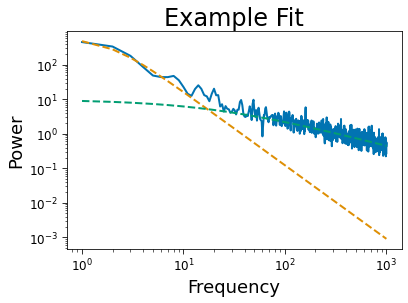

In [5]:
plt.figure(0)
ind = 0
plt.plot(psd.freqs, psd.powers[ind])
for p in psd.params[ind].reshape(2, -1):
    plt.loglog(psd.freqs, 10**expo_const_function(psd.freqs, *p), ls='--')
    
plt.title('Example Fit')
plt.ylabel('Power')
plt.xlabel('Frequency');

## R-Squared

Ttest_indResult(statistic=12.589236794268505, pvalue=2.11235822278043e-35)

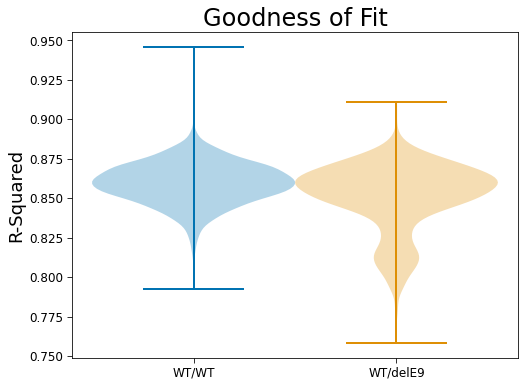

In [6]:
# Plot r-squared
rsq = psd.rsq.reshape(*orig_shape[:-1], -1)

rsq_wt = rsq[:, well_row_wt, well_col_wt].reshape(-1)
rsq_del = rsq[:, well_row_del, well_col_del].reshape(-1)

plt.figure(figsize=(8, 6))
plt.title('Goodness of Fit')
plt.violinplot(rsq_wt, positions=[1])
plt.violinplot(rsq_del, positions=[1.5])
plt.xticks([1, 1.5], ['WT/WT', 'WT/delE9'])
plt.ylabel('R-Squared');

ttest_ind(rsq_wt, rsq_del)

## Model Parameters

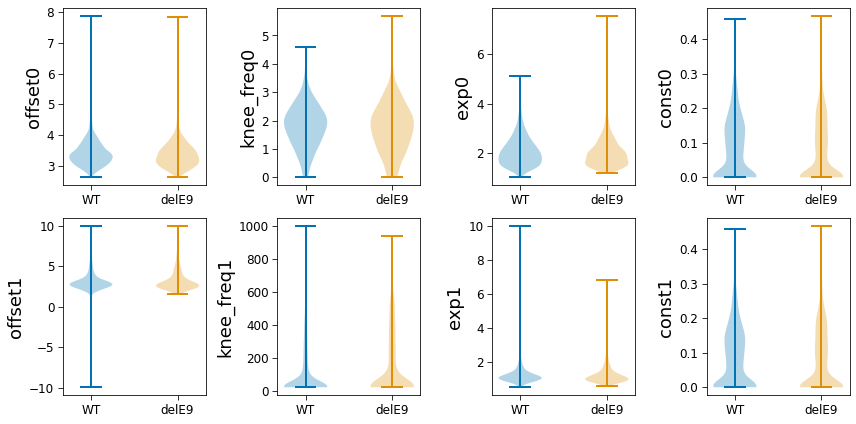

In [7]:
# Reshape parameters
params = psd.params.reshape(*orig_shape[:-1], -1)

params_wt = params[:, well_row_wt, well_col_wt].reshape(-1, 8)
params_del = params[:, well_row_del, well_col_del].reshape(-1, 8)

param_names = [p + j for j in ['0', '1'] for p in psd.param_names]
inds = [(i, j) for i in range(2) for j in range(4)]

# Plot
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(12, 6))

for i in range(8):
    ax_inds = inds[i]
    axes[ax_inds].violinplot(params_wt[:, i])
    axes[ax_inds].violinplot(params_del[:, i], positions=[2])
    axes[ax_inds].set_ylabel(param_names[i])
    axes[ax_inds].set_xticks([1, 2], ['WT', 'delE9'])
    
plt.tight_layout()

## Stats

In [8]:
# Stats
nround = 6

pmeans_wt = []
pstds_wt = []
pmeans_del = []
pstds_del = []
tstats = []
pvals = []

for i in range(8):
    p0, p1 = params_wt[:, i], params_del[:, i]
    pmeans_wt.append(p0.mean().round(nround))
    pmeans_del.append(p1.mean().round(nround))
    pstds_wt.append(p0.std().round(nround))
    pstds_del.append(p1.std().round(nround))
    t, p = ttest_ind(p0, p1)
    tstats.append(t)
    pvals.append(p)
    
# Organize into dataframe
df = pd.DataFrame()

df['Parameter'] = param_names
df['Mean (std.) WT/WT'] = [f"{m} ({s})" for m, s in
                           zip(pmeans_wt, pstds_wt)]

df['Mean (std.) WT/delE9'] = [f"{m} ({s})" for m, s in
                              zip(pmeans_del, pstds_del)]

df['tstat'] = np.array(tstats).round(nround)
df['pvalue'] = np.array(pvals).round(nround)

df

,Parameter,Mean (std.) WT/WT,Mean (std.) WT/delE9,tstat,pvalue
0,offset0,3.410264 (0.42105),3.379062 (0.448939),1.906936,0.056630
1,knee_freq0,1.805366 (0.778631),1.753553 (0.892865),1.645213,0.100037
2,exp0,2.116995 (0.628677),2.036419 (0.578124),3.548804,0.000393
3,const0,0.08888 (0.08824),0.076654 (0.087166),3.707844,0.000213
4,offset1,3.146477 (1.242086),3.408383 (1.596927),-4.869735,0.000001
5,knee_freq1,101.735789 (146.612309),155.941696 (192.547663),-8.425352,0.000000
6,exp1,1.234553 (0.539205),1.286833 (0.594801),-2.449597,0.014362
7,const1,0.088804 (0.08816),0.07666 (0.087154),3.684912,0.000233


## Timescale Variation

Each trace is the mean of 16 electrodes per well. There are 24 wells (traces) per WT/WT and WT/delE9.

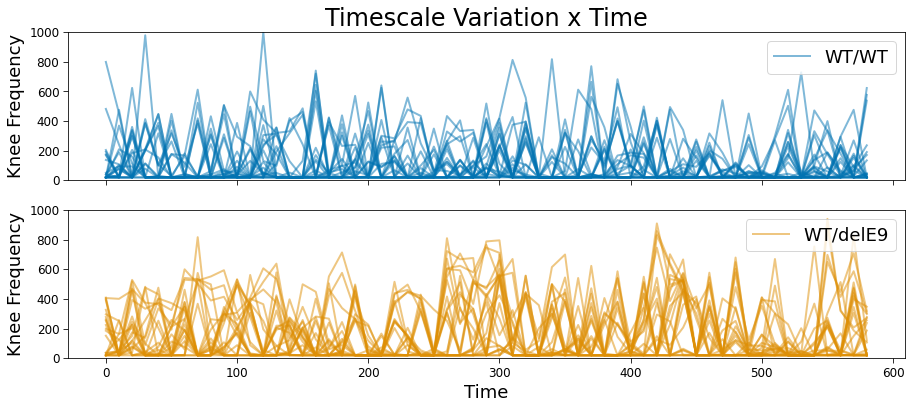

In [9]:
fig, axes = plt.subplots(nrows=2, figsize=(15, 6), sharex=True)

kf1 = psd.params[:, 5]
kf1 = kf1.reshape(*orig_shape[:-1])

times = np.arange(0, len(kf1) * 10, 10)

label0 = 'WT/WT'
label1 = 'WT/delE9'
            
for wr in range(6):
    for wc in range(8):    
        if wells[wr, wc] == 'WT/WT':
            axes[0].plot(times, kf1[:, wr, wc],  label=label0,
                         color='C0', alpha=.5)
            label0 = ''
        else:
            axes[1].plot(times, kf1[:, wr, wc], label=label1,
                         color='C1', alpha=.5)
            label1 = ''
            
axes[0].set_ylim(0, 1000)
axes[1].set_ylim(0, 1000)
axes[0].set_title('Timescale Variation x Time')
axes[0].set_ylabel('Knee Frequency')
axes[1].set_ylabel('Knee Frequency')
axes[1].set_xlabel('Time')
axes[0].legend(loc='upper right');
axes[1].legend(loc='upper right');

## Slow vs Fast Timescales

In [10]:
# Organize spectral results
_powers = psd.powers.reshape(*orig_shape[:-1], -1)
_powers_fit = psd.powers_fit.reshape(*orig_shape[:-1], -1)
_params = psd.params.reshape(*orig_shape[:-1], 8)

powers_wt = np.zeros((3, len(_powers), 24, psd.powers.shape[-1]))
powers_del = np.zeros((3, len(_powers), 24, psd.powers.shape[-1]))

for wr in range(6):
    for wc in range(8):
        for ind in range(len(_powers)):
            if wells[wr, wc] == 'WT/WT':
                powers_wt[0][ind] = _powers[ind, wr, wc]
                powers_wt[1][ind] = 10**expo_const_function(psd.freqs, *_params[ind, wr, wc][-4:])
                powers_wt[2][ind] = 10**expo_const_function(psd.freqs, *_params[ind, wr, wc][:4])
            else:
                powers_del[0][ind] = _powers[ind, wr, wc]
                powers_del[1][ind] = 10**expo_const_function(psd.freqs, *_params[ind, wr, wc][-4:])
                powers_del[2][ind] = 10**expo_const_function(psd.freqs, *_params[ind, wr, wc][:4])

powers_wt = powers_wt.mean(axis=2)
powers_del = powers_del.mean(axis=2)

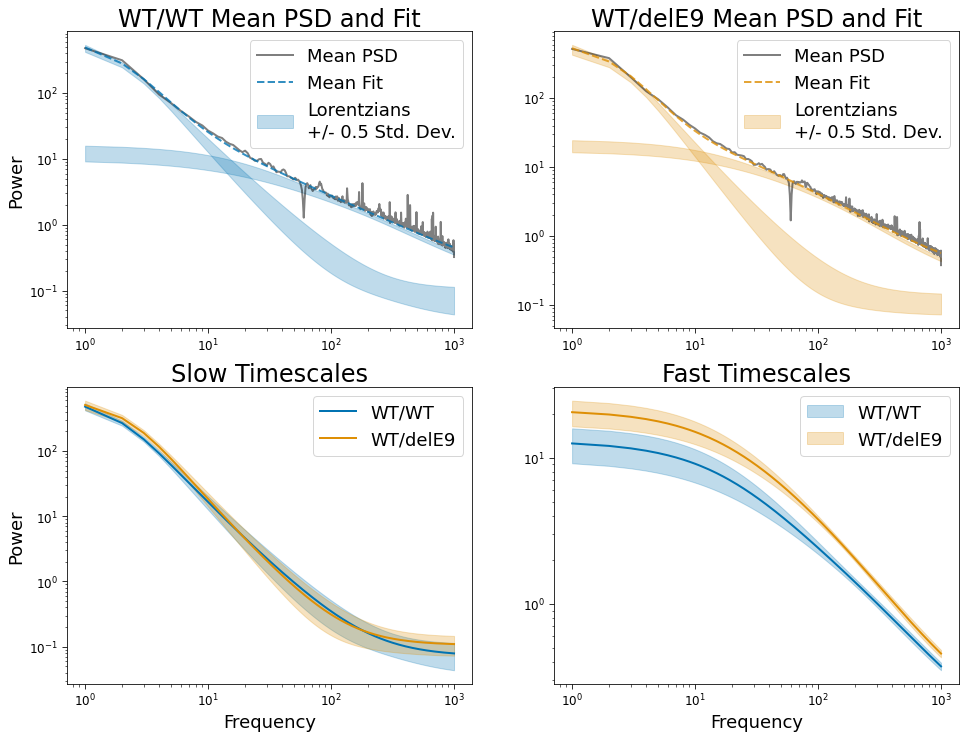

In [11]:
# Plot
fig, axes = plt.subplots(ncols=2, nrows=2, figsize=(16, 12))

std = .5

# WT/WT
axes[0][0].loglog(psd.freqs, powers_wt[0].mean(axis=0), color='k',
                  alpha=.5, lw=2, ls='solid', label='Mean PSD')

axes[0][0].loglog(psd.freqs, (powers_wt[1] + powers_wt[2]).mean(axis=0), color='C0',
                  alpha=.8, lw=2, ls='--', label='Mean Fit')

for i in range(2):
    pmean = powers_wt[i+1].mean(axis=0)
    pstd = powers_wt[i+1].std(axis=0) * std
    label = 'Lorentzians\n+/- 0.5 Std. Dev.' if i == 0 else ''
    axes[0][0].fill_between(psd.freqs, pmean-pstd, pmean+pstd,
                            alpha=.25, color='C0', label=label)
    
# WT/delE9
axes[0][1].loglog(psd.freqs, powers_del[0].mean(axis=0), color='k',
                  alpha=.5, lw=2, ls='solid', label='Mean PSD')

axes[0][1].loglog(psd.freqs, (powers_del[1] + powers_del[2]).mean(axis=0), color='C1',
                  alpha=.8, lw=2, ls='--', label='Mean Fit')
for i in range(2):
    pmean = powers_del[i+1].mean(axis=0)
    pstd = powers_del[i+1].std(axis=0) * std
    label = 'Lorentzians\n+/- 0.5 Std. Dev.' if i == 0 else ''
    axes[0][1].fill_between(psd.freqs, pmean-pstd, pmean+pstd,
                            alpha=.25, color='C1', label=label)


# Bottom left
axes[1][0].loglog(psd.freqs, powers_wt[2].mean(axis=0),
                  color='C0', label='WT/WT')
pmean = powers_wt[2].mean(axis=0)
pstd = powers_wt[2].std(axis=0) * std
axes[1][0].fill_between(psd.freqs, pmean-pstd, pmean+pstd, alpha=.25, color='C0')

axes[1][0].loglog(psd.freqs, powers_del[2].mean(axis=0),
                  color='C1', label='WT/delE9')
pmean = powers_del[2].mean(axis=0)
pstd = powers_del[2].std(axis=0) * std
axes[1][0].fill_between(psd.freqs, pmean-pstd, pmean+pstd, alpha=.25, color='C1')

# Bottom right
axes[1][1].loglog(psd.freqs, powers_wt[1].mean(axis=0), color='C0')
pmean = powers_wt[1].mean(axis=0)
pstd = powers_wt[1].std(axis=0) * std
axes[1][1].fill_between(psd.freqs, pmean-pstd, pmean+pstd, alpha=.25,
                        color='C0', label='WT/WT')

axes[1][1].loglog(psd.freqs, powers_del[1].mean(axis=0), color='C1')
pmean = powers_del[1].mean(axis=0)
pstd = powers_del[1].std(axis=0) * std
axes[1][1].fill_between(psd.freqs, pmean-pstd, pmean+pstd, alpha=.25,
                        color='C1', label='WT/delE9')

axes[0][0].set_title('WT/WT Mean PSD and Fit')
axes[0][1].set_title('WT/delE9 Mean PSD and Fit')
axes[1][0].set_title('Slow Timescales')
axes[1][1].set_title('Fast Timescales')

axes[0][0].legend()
axes[0][1].legend()
axes[1][0].legend()
axes[1][1].legend()

axes[1][0].set_xlabel('Frequency')
axes[1][1].set_xlabel('Frequency')
axes[0][0].set_ylabel('Power')
axes[1][0].set_ylabel('Power');

In [12]:
# Split fits in low and high gamma
freqs = freqs[1:]

fit_wt = powers_wt[[1, 2]].sum(axis=0)
psd_wt = powers_wt[0]

fit_del = powers_del[[1, 2]].sum(axis=0)
psd_del = powers_del[0]

ap_rm_wt = psd_wt - fit_wt
ap_rm_del = psd_del - fit_del

# Get low and high gamma indices
inds_lo = np.where(
    (freqs >= 30) &
    (freqs <= 100)
)[0]

inds_hi = np.where(
    (freqs > 100) &
    (freqs <= 200)
)[0]

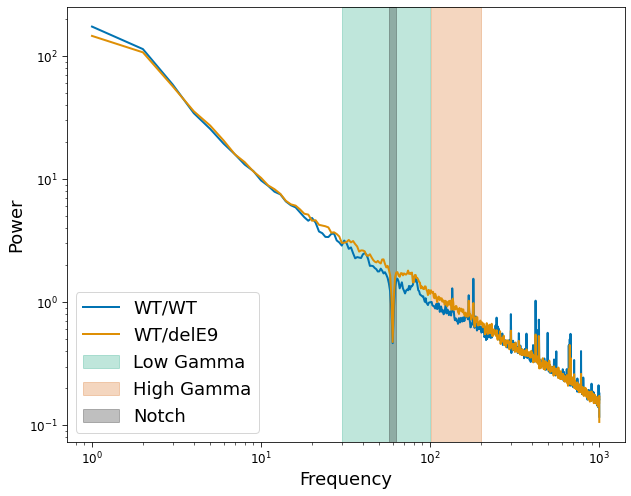

In [13]:
plt.figure(figsize=(10, 8))

plt.loglog(freqs, psd_wt.mean(axis=0) / psd_wt.mean(axis=0).mean(), label='WT/WT')
plt.loglog(freqs, psd_del.mean(axis=0)/ psd_del.mean(axis=0).mean(), label='WT/delE9')

plt.axvspan(30, 100,  alpha=0.25, color='C2', label='Low Gamma')
plt.axvspan(101, 200, alpha=0.25, color='C3', label='High Gamma')
plt.axvspan(57, 63,  alpha=0.25, color='k',  label='Notch')


plt.xlabel('Frequency')
plt.ylabel('Power')
plt.legend();

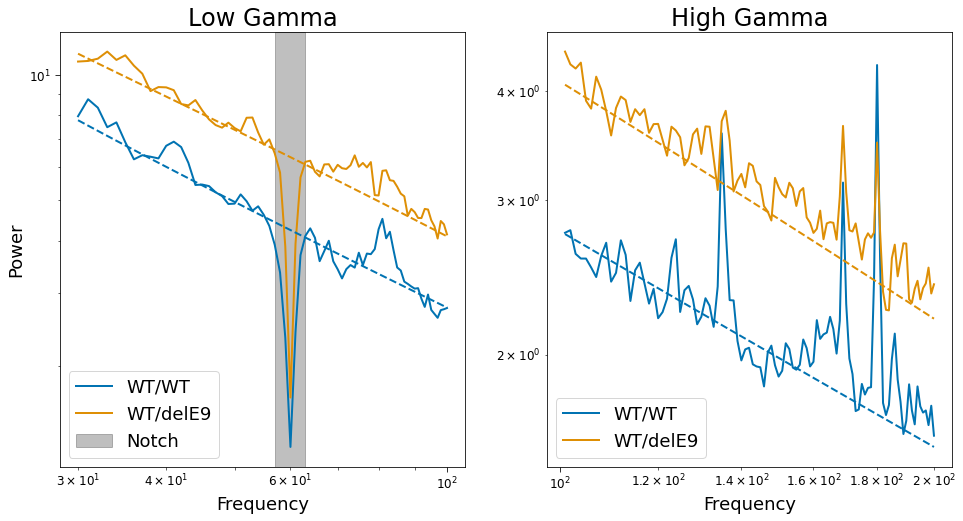

In [33]:
def _plot(freqs, inds, psd, fit, ax, shift=0, kwargs_loglog={}, kwargs_axhline={}):

    _freqs = freqs[inds]
    _ap_rm = psd[:, inds].mean(axis=0) -  fit[:, inds].mean(axis=0)
    
    ax.loglog(_freqs, _ap_rm + shift, **kwargs_loglog)
    ax.axhline(shift, color='k', ls='--', **kwargs_axhline)
    
fig, axes = plt.subplots(ncols=2, figsize=(16, 8))

axes[0].loglog(freqs[inds_lo], psd_wt[:, inds_lo].mean(axis=0), color='C0', label='WT/WT')
axes[0].loglog(freqs[inds_lo], psd_del[:, inds_lo].mean(axis=0), color='C1', label='WT/delE9')

axes[0].loglog(freqs[inds_lo], fit_wt[:, inds_lo].mean(axis=0), color='C0', ls='--')
axes[0].loglog(freqs[inds_lo], fit_del[:, inds_lo].mean(axis=0), color='C1', ls='--')

axes[1].loglog(freqs[inds_hi], psd_wt[:, inds_hi].mean(axis=0), color='C0', label='WT/WT')
axes[1].loglog(freqs[inds_hi], psd_del[:, inds_hi].mean(axis=0), color='C1', label='WT/delE9')

axes[1].loglog(freqs[inds_hi], fit_wt[:, inds_hi].mean(axis=0), color='C0', ls='--')
axes[1].loglog(freqs[inds_hi], fit_del[:, inds_hi].mean(axis=0), color='C1', ls='--')
    


axes[0].set_title('Low Gamma')
axes[1].set_title('High Gamma')
axes[0].set_ylabel('Power')
axes[0].set_xlabel('Frequency')
axes[1].set_xlabel('Frequency')

axes[0].axvspan(57, 63,  alpha=0.25, color='k',  label='Notch')


axes[0].legend(loc='lower left')
axes[1].legend(loc='lower left');

In [34]:
from functools import partial
from itertools import repeat
from multiprocessing import Pool
from tqdm.notebook import tqdm

from fooof import FOOOF
from fooof.sim.gen import gen_periodic

def fit_periodic(freqs, powers, **kwargs):

    # Hack fooof periodic fitting
    fm = FOOOF(**kwargs)
    fm.freq_range = (freqs[0], freqs[-1])
    fm.freqs = freqs
    fm.freq_res = freqs[1] - freqs[0]
    fm._spectrum_flat = np.log10(powers)
    fm.fooofed_spectrum_ = powers
    fm._ap_fit = np.ones(len(powers))
    gaussian_params = fm._fit_peaks(powers)
    
    # order: [CF, PW, BW]
    peak_fit = gen_periodic(fm.freqs, np.ndarray.flatten(gaussian_params))
    peak_params = fm._create_peak_params(gaussian_params)
    
    return peak_fit, peak_params


def plot_periodic(freqs, psd, fit, inds, ax, C0=None, C1=None, label=None,
                  show_legend=False, plot_notch=False, shift=1, **init_kwargs):
    
    # Get ap-removed psd and shift to positive / log-able values
    _freqs = freqs[inds]
    _ap_rm = psd[:, inds].mean(axis=0) -  fit[:, inds].mean(axis=0)
    _ap_rm = _ap_rm + shift 
    
    # Ensure log-able
    le_zero = np.where(_ap_rm <= 0)[0]
    if len(le_zero) > 0:
        _ap_rm[le_zero] = 1e-6
        
    # Fit
    _fit, _params = fit_periodic(_freqs, _ap_rm, **init_kwargs)
    
    label = label if label is not None else 'Adjusted Power'
    ax.loglog(_freqs, _ap_rm, label=label, color=C0, alpha=.5)
    ax.loglog(_freqs, 10**_fit, ls='--', label='Periodic Fit', color=C1)
    ax.axhline(shift, color='k', ls='--', label='Aperiodic Baseline')
    ax.set_ylim(.5, 5)
    
    if plot_notch:
        ax.axvspan(57, 63,  alpha=0.25, color='k',  label='Notch')
        
    if show_legend:
        ax.legend(fontsize=14)
        
    return _fit, _params

def fit_parallel(arrays, inds=inds):
    
    freqs, psd, ap_fit = arrays

    # Get ap-removed psd and shift to positive / log-able values
    _freqs = freqs[inds]
    _ap_rm = psd[inds] - ap_fit[inds]
    _ap_rm = _ap_rm + 1 
    
    # Ensure log-able
    le_zero = np.where(_ap_rm <= 0)[0]
    if len(le_zero) > 0:
        _ap_rm[le_zero] = 1e-6
        
    # Fit
    init_kwargs = dict(max_n_peaks=4, peak_width_limits=(0, 5), min_peak_height=1.1)
    periodic_fit, params = fit_periodic(_freqs, _ap_rm, **init_kwargs)
    
    return 10**periodic_fit, _ap_rm, params

In [35]:
# Utils
rfreqs = repeat(freqs)
pfunc_lo = partial(fit_parallel, inds=inds_lo)
pfunc_hi = partial(fit_parallel, inds=inds_hi)

# Fit WT/WT
arrays = zip(rfreqs, psd_wt, fit_wt)
with Pool(processes=12) as pool:   
    mapping = pool.imap(pfunc_lo, arrays)
    results = list(tqdm(mapping, total=len(psd_wt)))
    
periodic_fit_wt_lo = np.array([i[0] for i in results])
aperiodic_rm_wt_lo = np.array([i[1] for i in results])
periodic_params_wt_lo = [i[2] for i in results]

arrays = zip(rfreqs, psd_wt, fit_wt)
with Pool(processes=12) as pool:   
    mapping = pool.imap(pfunc_hi, arrays)
    results = list(tqdm(mapping, total=len(psd_wt)))
    
periodic_fit_wt_hi = np.array([i[0] for i in results])
aperiodic_rm_wt_hi = np.array([i[1] for i in results])
periodic_params_wt_hi = [i[2] for i in results]

# Fit WT/delE9
arrays = zip(rfreqs, psd_del, fit_del)
with Pool(processes=12) as pool:   
    mapping = pool.imap(pfunc_lo, arrays)
    results = list(tqdm(mapping, total=len(psd_del)))
    
periodic_fit_del_lo = np.array([i[0] for i in results])
aperiodic_rm_del_lo = np.array([i[1] for i in results])
periodic_params_del_lo = [i[2] for i in results]


arrays = zip(rfreqs, psd_del, fit_del)
with Pool(processes=12) as pool:   
    mapping = pool.imap(pfunc_hi, arrays)
    results = list(tqdm(mapping, total=len(psd_del)))
    
periodic_fit_del_hi = np.array([i[0] for i in results])
aperiodic_rm_del_hi = np.array([i[1] for i in results])
periodic_params_del_hi = [i[2] for i in results]

  0%|          | 0/59 [00:00<?, ?it/s]

  0%|          | 0/59 [00:00<?, ?it/s]

  0%|          | 0/59 [00:00<?, ?it/s]

  0%|          | 0/59 [00:00<?, ?it/s]

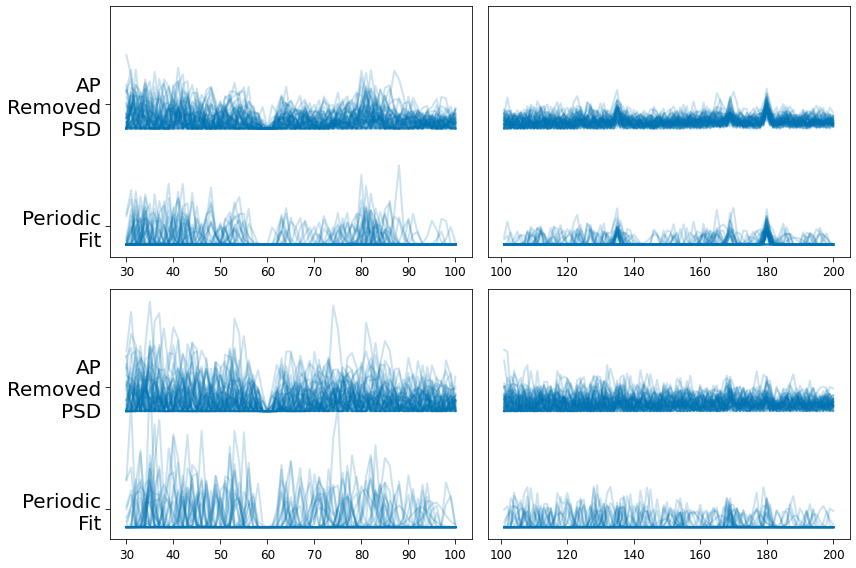

In [36]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 8))

# WT/WT
shift = 20
a = .2
for p in aperiodic_rm_wt_lo:
    axes[0][0].plot(freqs[inds_lo], p+shift, color='C0', alpha=a)
    
for p in periodic_fit_wt_lo:
    axes[0][0].plot(freqs[inds_lo], p, color='C0', alpha=a)
    
for p in aperiodic_rm_wt_hi:
    axes[0][1].plot(freqs[inds_hi], p+shift, color='C0', alpha=a)
    
for p in periodic_fit_wt_hi:
    axes[0][1].plot(freqs[inds_hi], p, color='C0', alpha=a)
    
# WT/delE9
for p in aperiodic_rm_del_lo:
    axes[1][0].plot(freqs[inds_lo], p+shift, color='C0', alpha=a)
    
for p in periodic_fit_del_lo:
    axes[1][0].plot(freqs[inds_lo], p, color='C0', alpha=a)
    
for p in aperiodic_rm_del_hi:
    axes[1][1].plot(freqs[inds_hi], p+shift, color='C0', alpha=a)

for p in periodic_fit_del_hi:
    axes[1][1].plot(freqs[inds_hi], p, color='C0', alpha=a)

#
for ax in [axes[0][0], axes[1][0]]:
    ax.set_yticks([4, shift+4], labels=['Periodic\nFit', 'AP\nRemoved\nPSD'], size=20)
    
axes[0][1].set_yticks([])
axes[1][1].set_yticks([])

for ax in axes.flatten():
    #ax.set_ylim(-1, 10)
    ax.set_ylim(-1, 40)

plt.tight_layout()